In [ ]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


In [ ]:
def full_adder(qc, a, b, cin, sum_bit, cout, temp):
    qc.cx(a, temp)
    qc.cx(b, temp)

    qc.cx(temp, sum_bit)
    qc.cx(cin, sum_bit)

    qc.ccx(a, b, cout)
    qc.ccx(cin, temp, cout)

    qc.cx(b, temp)
    qc.cx(a, temp)

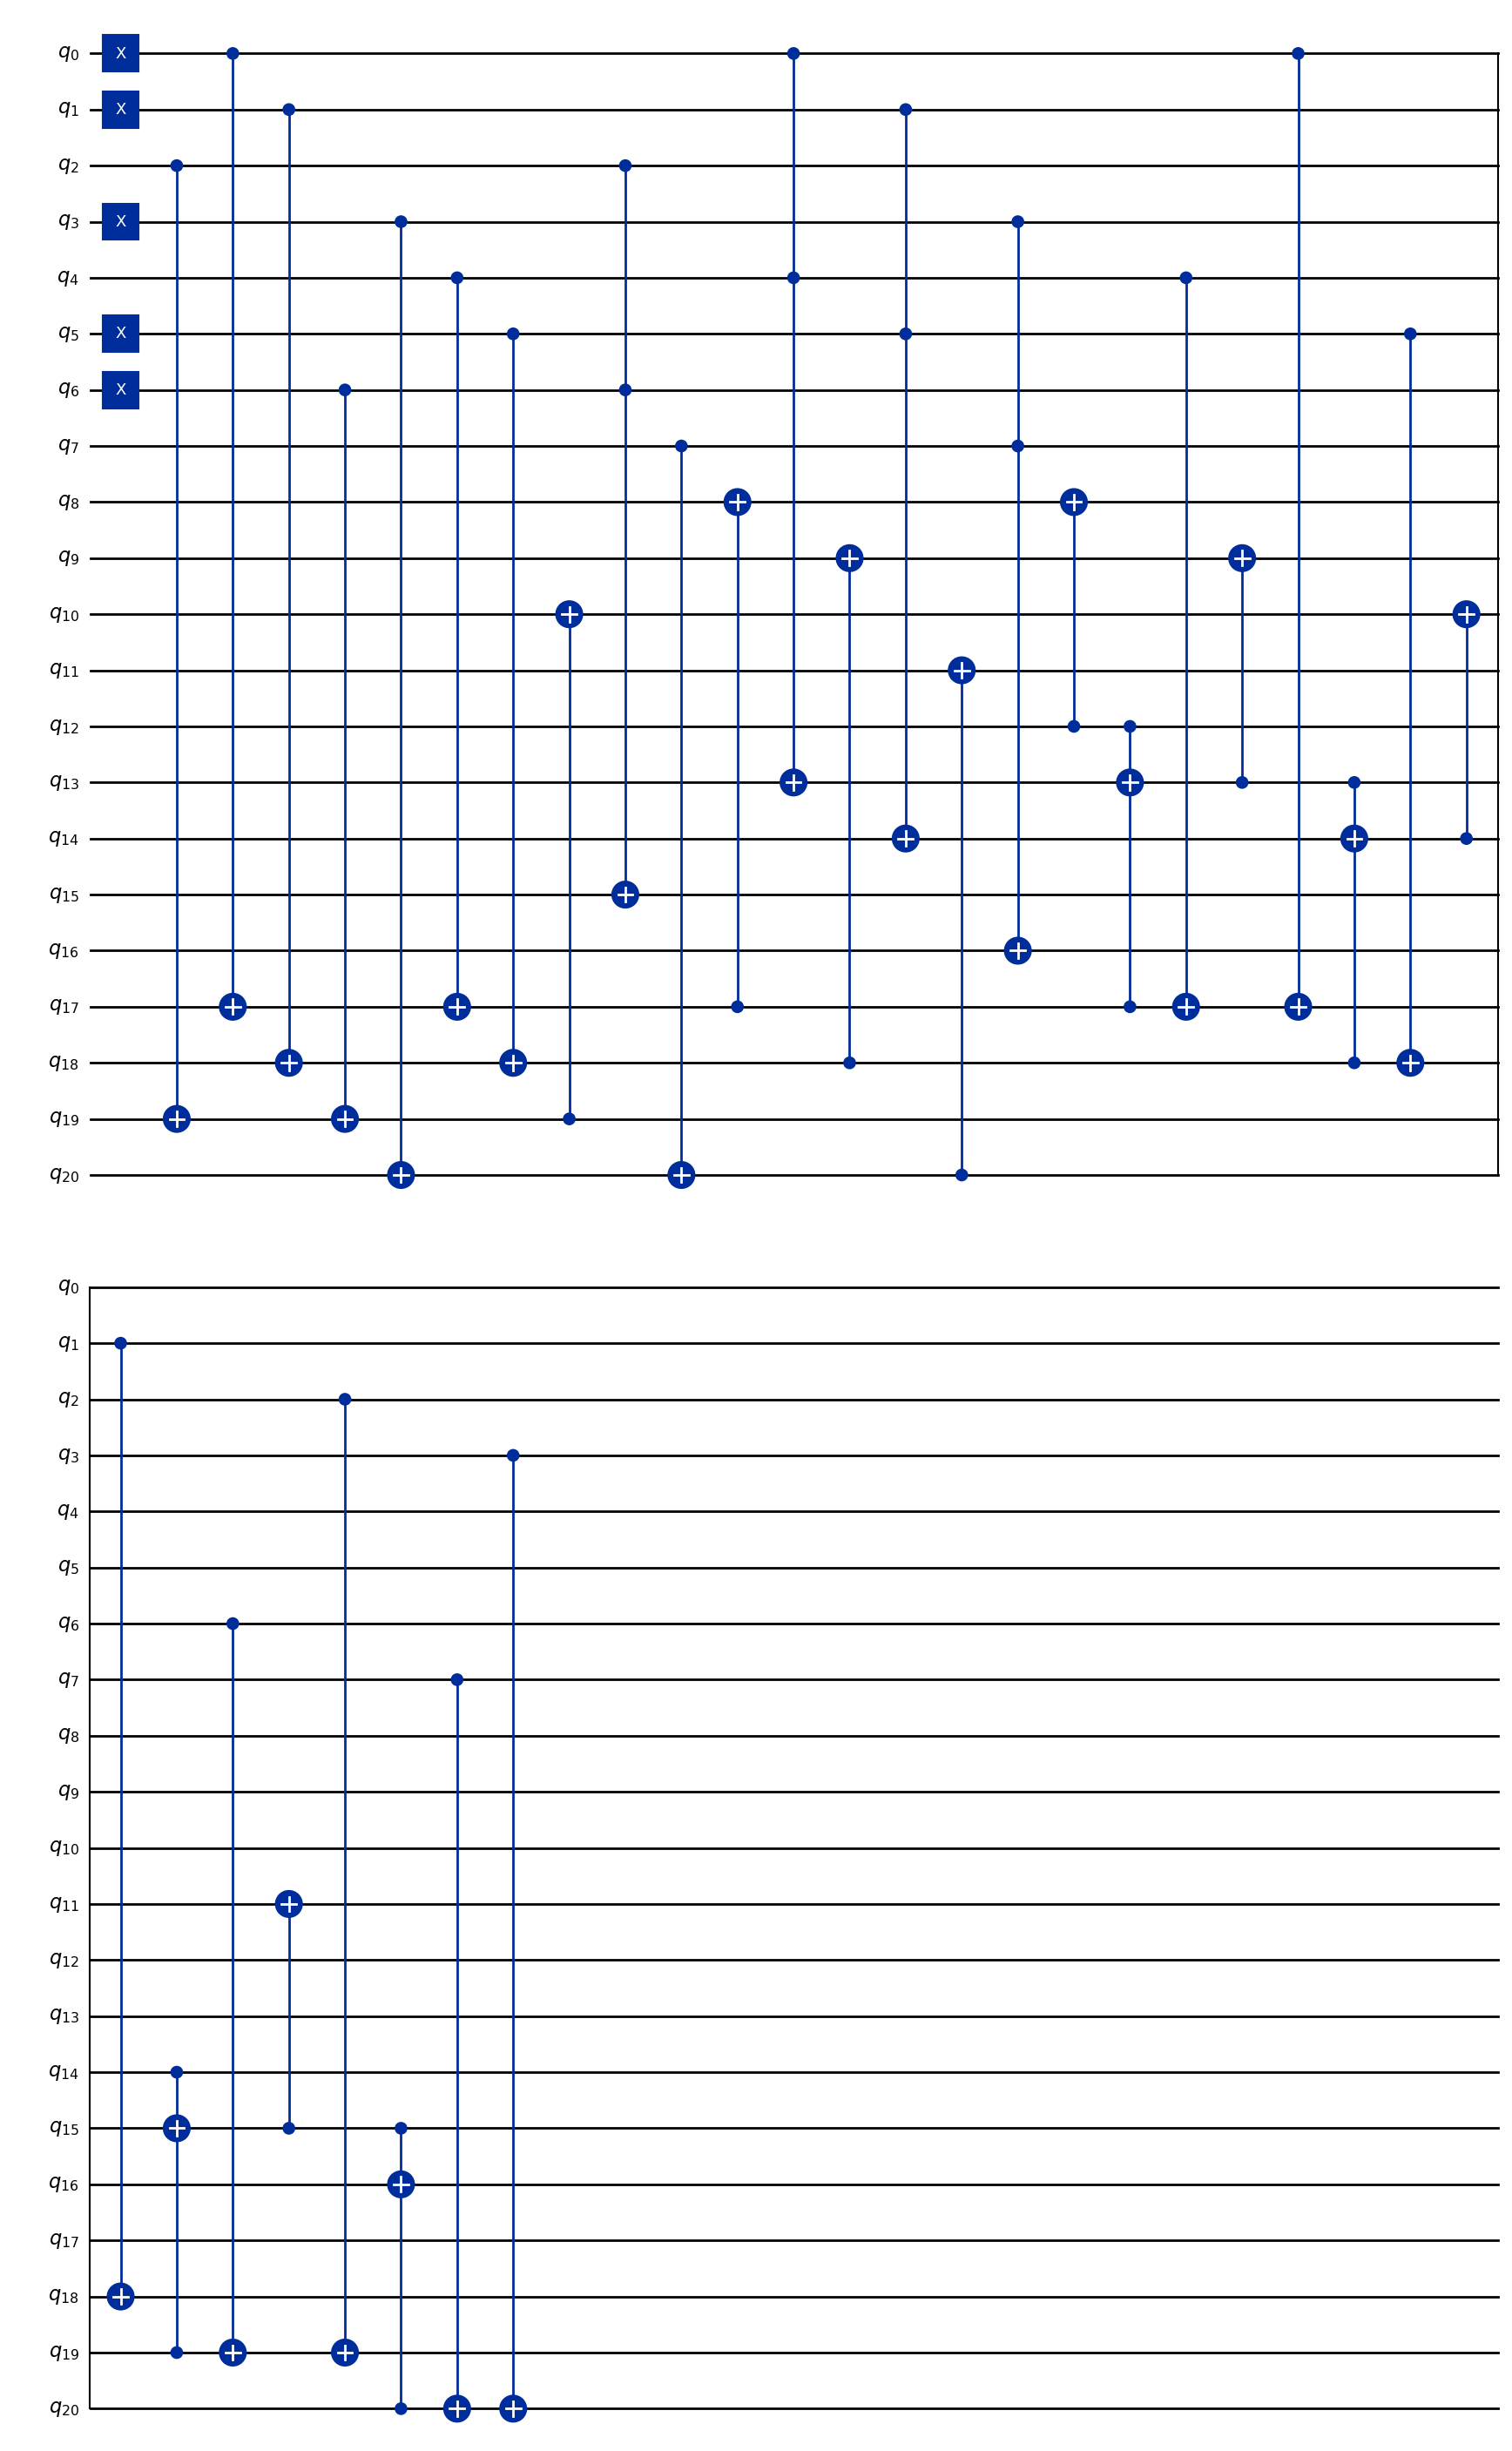

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(21)

# A: 0-3
# B: 4-7
# Sum: 8-11
# Carry: 12-16
# Temp: 17-20

# Example: A = 1011
qc.x(0)
qc.x(1)
qc.x(3)

# Example: B = 0110
qc.x(5)
qc.x(6)

# Ripple carry chain
full_adder(qc, 0, 4, 12, 8, 13, 17)
full_adder(qc, 1, 5, 13, 9, 14, 18)
full_adder(qc, 2, 6, 14, 10, 15, 19)
full_adder(qc, 3, 7, 15, 11, 16, 20)

# Draw circuit
qc.draw('mpl')

In [ ]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# Add measurement
qc.measure_all()

sim = AerSimulator()
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'000011100000101101011': 1024}
